In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics

import esc_fresnel.efc as efc



/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-03-26 14:01:53,146	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
wfe_dir = 'V20250325-cropped'
wfe_dir = 'V20250326-cropped'

dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

0


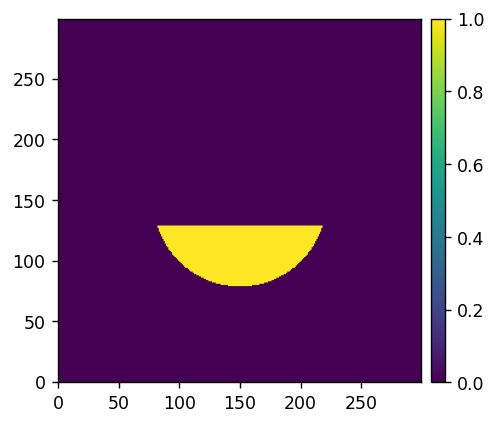

1


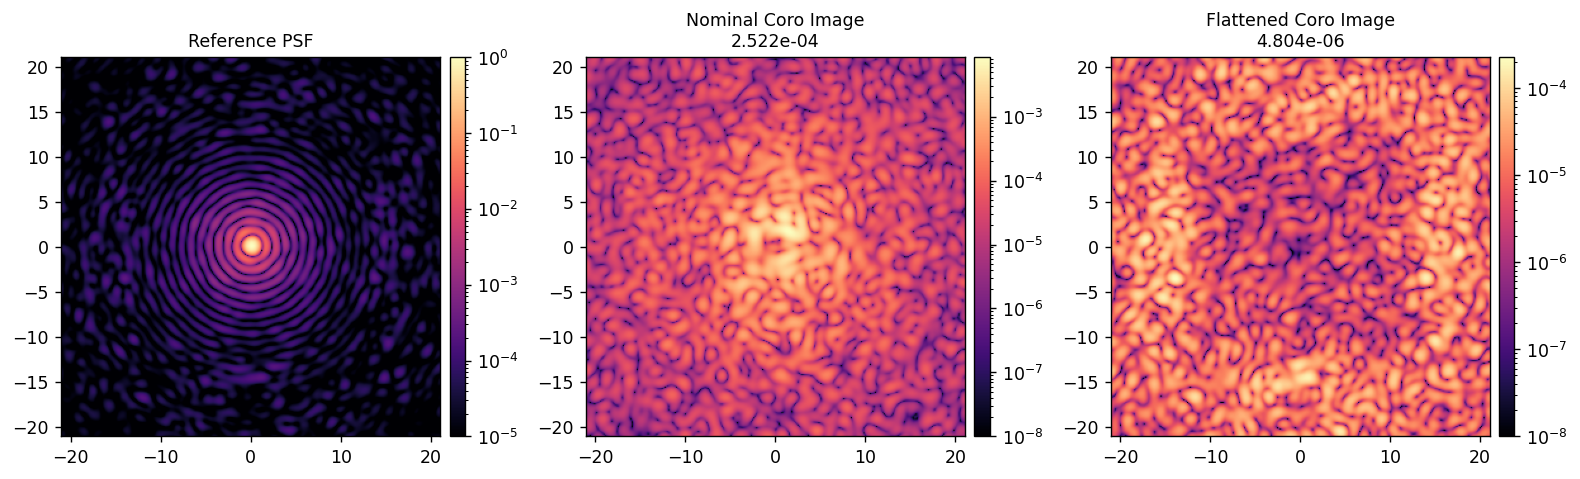

In [3]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 300

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
M.zero_dm()
coro_im_0 = M.snap()

M.reset_dm()
coro_im_flat = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_0 = utils.mean(coro_im_0, coro_mask)
contrast_flat = utils.mean(coro_im_flat, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_0, coro_im_flat],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Nominal Coro Image\n{contrast_0:.3e}',
            f'Flattened Coro Image\n{contrast_flat:.3e}',],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-8)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [4]:
reload(efc)

jac = efc.compute_jacobian(
    M, 
    1e-9,
    coro_mask, 
    plot=True,
)

In [5]:
calib_data = {
    'jacobian':jac,
}

utils.save_pickle(esc_fresnel.path/'wfe-maps'/wfe_dir/'efc_mono_calib.pkl', calib_data)

Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/efc_mono_calib.pkl


In [5]:
calib_data = utils.load_pickle(esc_fresnel.path/'data'/'esc_fresnel_mono_efc_calib.pkl')
jac = calib_data['jacobian']

In [6]:
reload(utils)
cm20 = utils.beta_reg(jac, -2)
cm25 = utils.beta_reg(jac, -2.5)
# cm30 = utils.beta_reg(jac, -3)
# cm35 = utils.beta_reg(jac, -3.5)
# cm40 = utils.beta_reg(jac, -4)
cm45 = utils.beta_reg(jac, -4.5)
cm50 = utils.beta_reg(jac, -5)

In [7]:
M.reset_dm()
efc_data = {
    'images':[coro_im_flat],
    'contrasts':[contrast_flat],
    'commands':[],
    'efields':[],
    'del_commands':[],
    'pixelscale':M.camsci_pxscl_lamDc,
    'control_mask':coro_mask, 
}

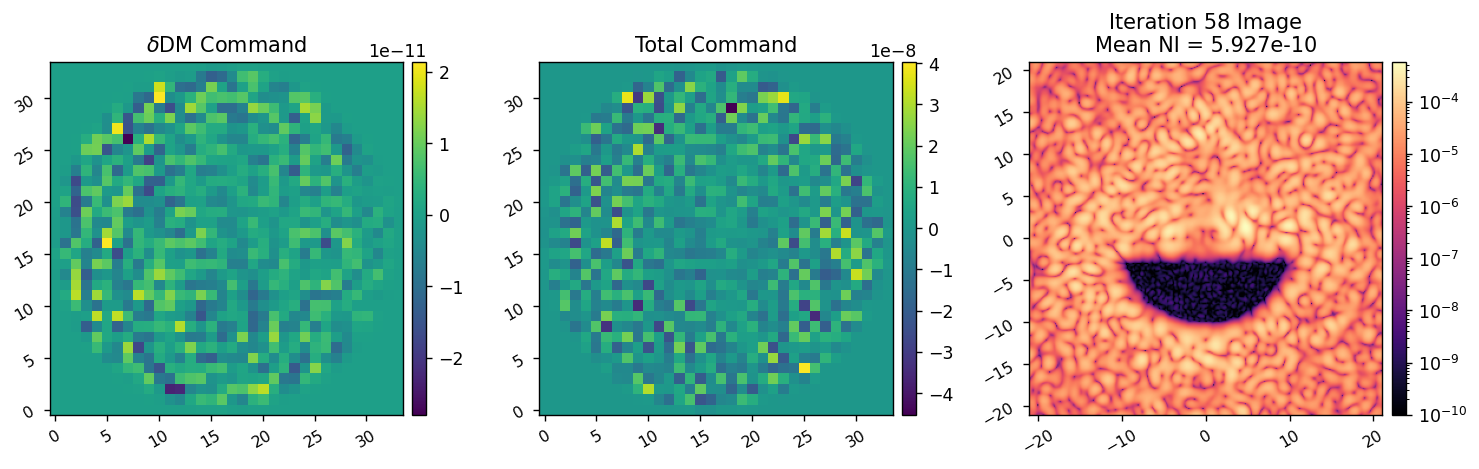

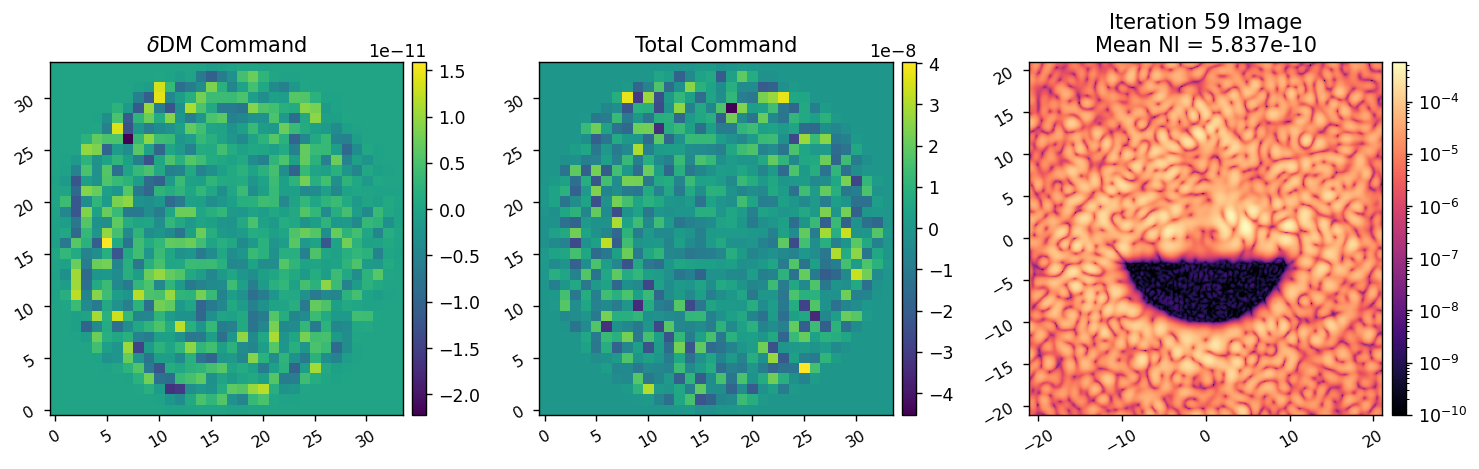

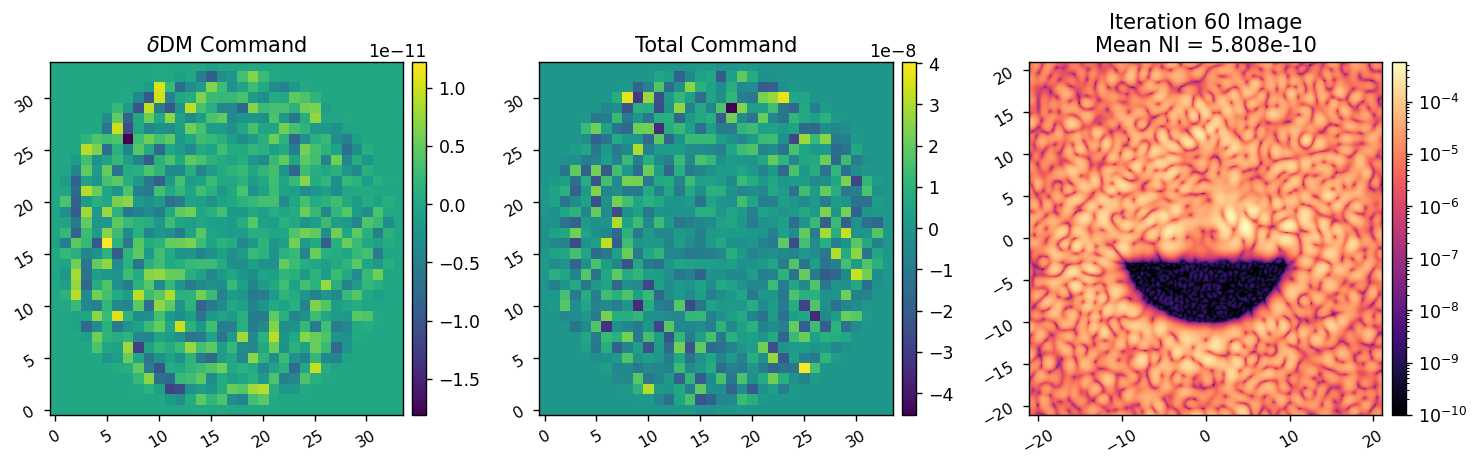

In [27]:
reload(efc)

efc_data = efc.run(
    M,
    # cm20,
    cm25,
    # cm40,
    # cm45,
    # cm50,
    coro_mask,
    M.dm_mask,
    efc_data,
    num_iterations=3,
    plot=1,
    vmin=1e-10,
)

In [29]:
utils.save_pickle(esc_fresnel.path/'data'/'esc_fresnel_efc_data.pkl', efc_data)

Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/data/esc_fresnel_efc_data.pkl


In [29]:
utils.save_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-8.fits', efc_data['commands'][4])
utils.save_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-9.fits', efc_data['commands'][14])
utils.save_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_5e-10.fits', efc_data['commands'][-1])

Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_dh_command_1e-8.fits
Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_dh_command_1e-9.fits
Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/V20250326-cropped/dm_dh_command_5e-10.fits


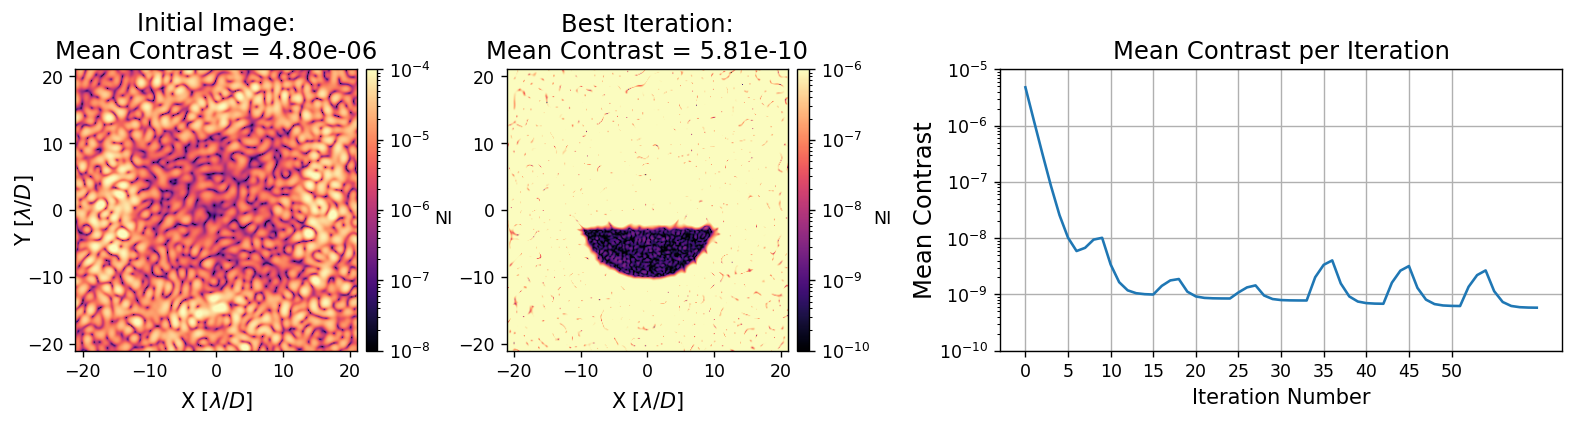

In [28]:
import esc_fresnel.imshows as imshows
reload(imshows)

imshows.plot_data_with_ref(
    efc_data, 
    im1vmin=1e-8, im1vmax=1e-4,
    im2vmin=1e-10, im2vmax=1e-6,
    vmin=1e-10, vmax=1e-5,
    xticks=np.arange(0,50.01,5)
)

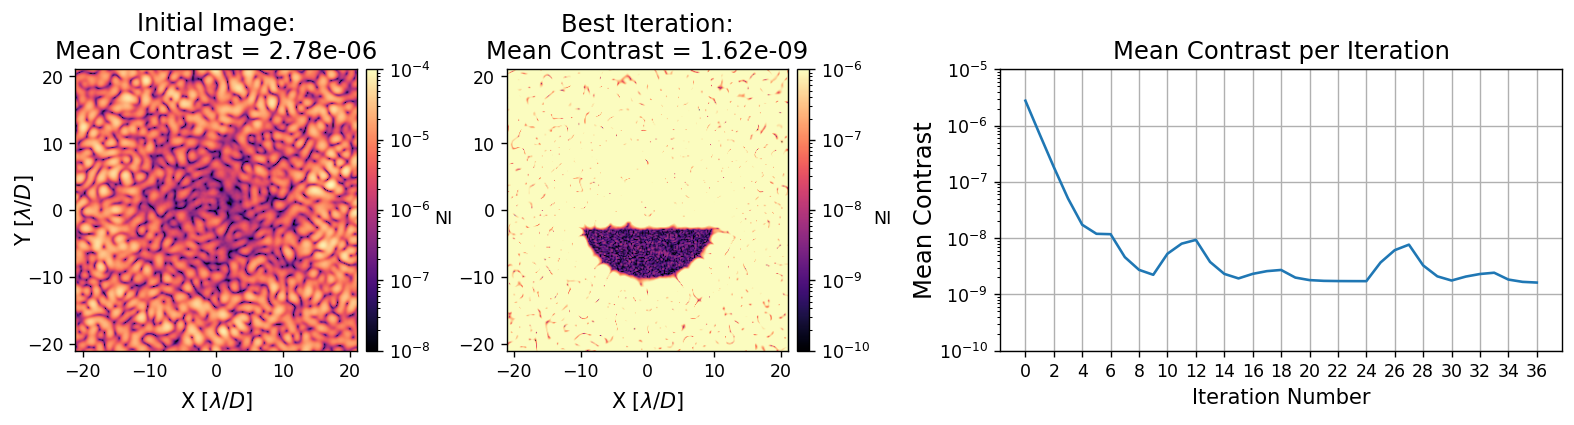

In [ ]:
import esc_fresnel.imshows as imshows
reload(imshows)

imshows.plot_data_with_ref(
    efc_data, 
    im1vmin=1e-8, im1vmax=1e-4,
    im2vmin=1e-10, im2vmax=1e-6,
    vmin=1e-10, vmax=1e-5,
)